In [2]:
# 1. Importar as bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Criando um gerador de números aleatórios para os nossos dados fictícios
np.random.seed(42)
n_clientes = 1000

# 2. Criar características realistas para os clientes
dados = {
    'Idade': np.random.randint(18, 70, size=n_clientes),
    'Tempo_Contrato_Meses': np.random.randint(1, 60, size=n_clientes),
    # Correção aqui: usamos np.round() envolvendo a geração de números aleatórios
    'Mensalidade_Euros': np.round(np.random.uniform(10.0, 100.0, size=n_clientes), 2),
    'Suporte_Ligacoes': np.random.randint(0, 10, size=n_clientes), # Número de vezes que ligou para o suporte
}

df_churn = pd.DataFrame(dados)

# 3. Criar a nossa variável alvo: 'Cancelou' (0 = Não, 1 = Sim)
probabilidade = (df_churn['Suporte_Ligacoes'] * 0.1) - (df_churn['Tempo_Contrato_Meses'] * 0.01) + 0.3
probabilidade = np.clip(probabilidade, 0, 1) # Garante que a probabilidade fica entre 0 e 1

df_churn['Cancelou'] = np.random.binomial(1, probabilidade)

# Visualizar as primeiras linhas do nosso novo projeto
print("--- PRIMEIROS CLIENTES DA BASE ---")
print(df_churn.head())

print("\n--- QUANTOS CLIENTES CANCELARAM? (0 = Não, 1 = Sim) ---")
print(df_churn['Cancelou'].value_counts())

--- PRIMEIROS CLIENTES DA BASE ---
   Idade  Tempo_Contrato_Meses  Mensalidade_Euros  Suporte_Ligacoes  Cancelou
0     56                    35              98.31                 6         1
1     69                    51              66.86                 5         0
2     46                    15              33.38                 8         1
3     32                    25              67.06                 3         1
4     60                    55              58.60                 0         0

--- QUANTOS CLIENTES CANCELARAM? (0 = Não, 1 = Sim) ---
Cancelou
0    556
1    444
Name: count, dtype: int64


In [3]:
# 1. Importar as ferramentas de Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 2. Definir as variáveis de entrada (X) e a variável alvo (y)
# Usaremos todas as colunas de características dos clientes
X_churn = df_churn.drop(columns=['Cancelou'])
y_churn = df_churn['Cancelou']

# 3. Dividir os dados em Treino (80%) e Teste (20%)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42
)

# 4. Criar e treinar o modelo de Regressão Logística
modelo_churn = LogisticRegression()
modelo_churn.fit(X_train_c, y_train_c)

# 5. Fazer previsões na base de teste
previsoes_churn = modelo_churn.predict(X_test_c)

# 6. Avaliar a Acurácia (Porcentagem de acertos gerais)
acuracia = accuracy_score(y_test_c, previsoes_churn)

print("--- MODELO DE CLASSIFICAÇÃO TREINADO ---")
print(f"Acurácia Geral do Modelo: {acuracia:.4f} (ou {acuracia*100:.1f}%)")

--- MODELO DE CLASSIFICAÇÃO TREINADO ---
Acurácia Geral do Modelo: 0.7350 (ou 73.5%)


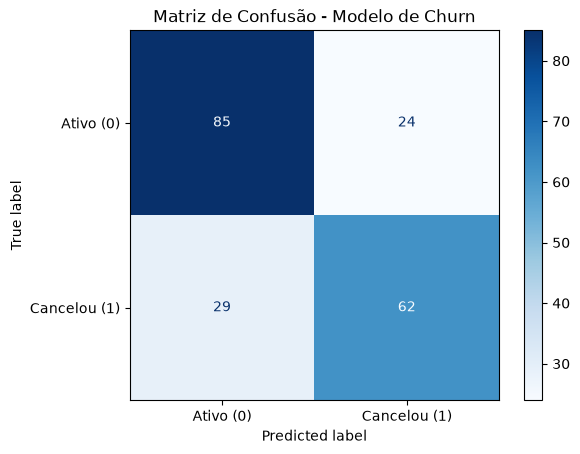

In [4]:
# 1. Importar a ferramenta de matriz de confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 2. Gerar a matriz comparando o gabarito (y_test_c) com as previsões (previsoes_churn)
matriz = confusion_matrix(y_test_c, previsoes_churn)

# 3. Exibir a matriz de forma gráfica e amigável
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['Ativo (0)', 'Cancelou (1)'])
disp.plot(cmap='Blues')

plt.title("Matriz de Confusão - Modelo de Churn")
plt.show()

--- MODELO DE ÁRVORE DE CLASSIFICAÇÃO TREINADO ---
Nova Acurácia Geral: 68.0%
Recall Anterior (Reg. Logística): 68.1%
Recall Atual (Árvore de Decisão): 83.5%


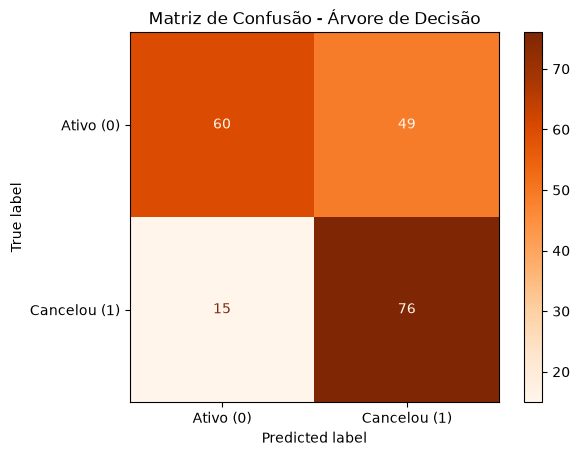

In [5]:
# 1. Importar a Árvore de Decisão para Classificação
from sklearn.tree import DecisionTreeClassifier

# 2. Criar e treinar o modelo
# Limitamos a profundidade (max_depth=4) para a árvore focar em regras gerais e não decorar os dados
modelo_arvore_c = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arvore_c.fit(X_train_c, y_train_c)

# 3. Fazer previsões
previsoes_arvore_c = modelo_arvore_c.predict(X_test_c)

# 4. Gerar a nova Matriz de Confusão
matriz_arvore = confusion_matrix(y_test_c, previsoes_arvore_c)

# 5. Calcular as métricas chave para comparação
acuracia_arv = accuracy_score(y_test_c, previsoes_arvore_c)

# Recall (Sensibilidade): Quanto menor o Falso Negativo, maior é o Recall!
# Fórmula: Verdadeiros Positivos / (Verdadeiros Positivos + Falsos Negativos)
recall_logistica = matriz[1, 1] / (matriz[1, 1] + matriz[1, 0])
recall_arvore = matriz_arvore[1, 1] / (matriz_arvore[1, 1] + matriz_arvore[1, 0])

print("--- MODELO DE ÁRVORE DE CLASSIFICAÇÃO TREINADO ---")
print(f"Nova Acurácia Geral: {acuracia_arv*100:.1f}%")
print(f"Recall Anterior (Reg. Logística): {recall_logistica*100:.1f}%")
print(f"Recall Atual (Árvore de Decisão): {recall_arvore*100:.1f}%")

# 6. Plotar a nova Matriz de Confusão para compararmos visualmente
disp_arv = ConfusionMatrixDisplay(confusion_matrix=matriz_arvore, display_labels=['Ativo (0)', 'Cancelou (1)'])
disp_arv.plot(cmap='Oranges') # Usando a cor laranja para diferenciar do modelo anterior

plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

--- MODELO RANDOM FOREST CLASSIFIER TREINADO ---
Acurácia Geral: 75.0%
Recall da Floresta: 75.8%


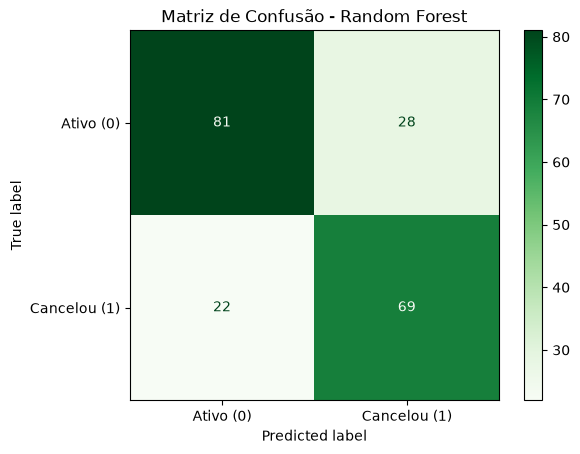

In [6]:
# 1. Importar o Random Forest para Classificação
from sklearn.ensemble import RandomForestClassifier

# 2. Criar e treinar o modelo
# Usaremos 100 árvores trabalhando juntas
modelo_floresta_c = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo_floresta_c.fit(X_train_c, y_train_c)

# 3. Fazer previsões
previsoes_floresta_c = modelo_floresta_c.predict(X_test_c)

# 4. Gerar a nova Matriz de Confusão
matriz_floresta = confusion_matrix(y_test_c, previsoes_floresta_c)

# 5. Calcular métricas para comparação
acuracia_floresta = accuracy_score(y_test_c, previsoes_floresta_c)
recall_floresta = matriz_floresta[1, 1] / (matriz_floresta[1, 1] + matriz_floresta[1, 0])

print("--- MODELO RANDOM FOREST CLASSIFIER TREINADO ---")
print(f"Acurácia Geral: {acuracia_floresta*100:.1f}%")
print(f"Recall da Floresta: {recall_floresta*100:.1f}%")

# 6. Plotar a nova Matriz de Confusão para compararmos
disp_floresta = ConfusionMatrixDisplay(confusion_matrix=matriz_floresta, display_labels=['Ativo (0)', 'Cancelou (1)'])
disp_floresta.plot(cmap='Greens') # Verde para celebrar o modelo final!

plt.title("Matriz de Confusão - Random Forest")
plt.show()